   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00
✅ All dependencies loaded successfully!
Mounted at /content/drive
DATASET OVERVIEW

Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

First few rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph           

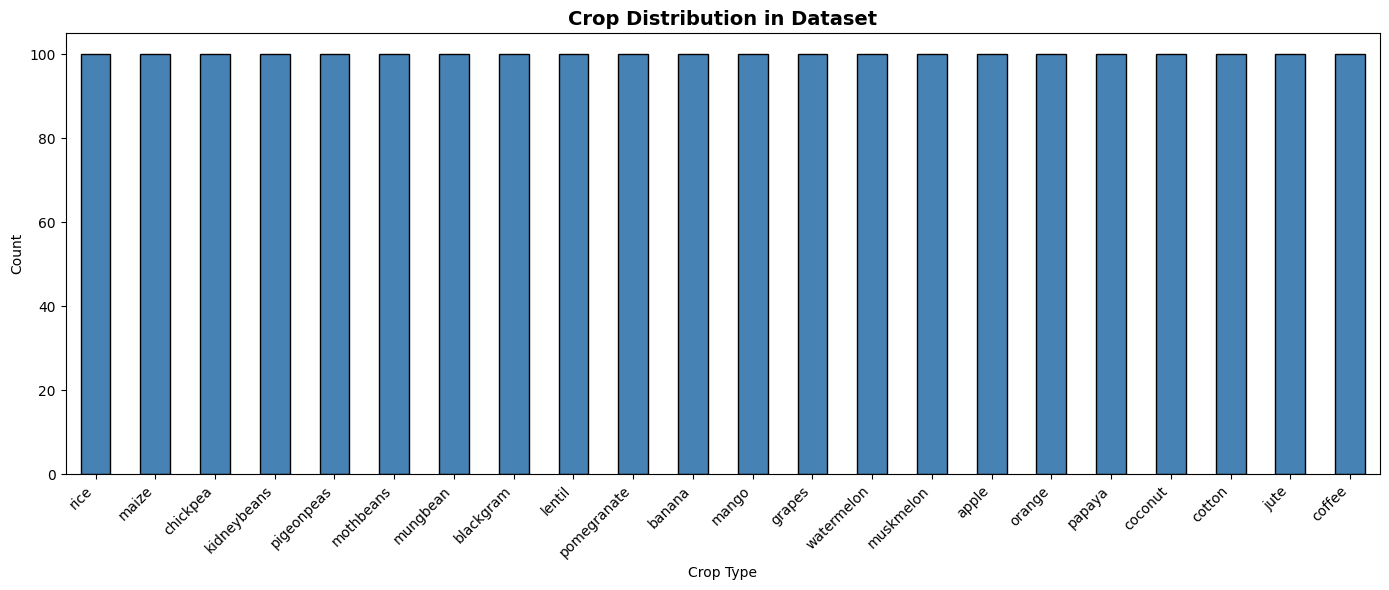


EXPLORATORY DATA ANALYSIS

📊 Feature Correlations:


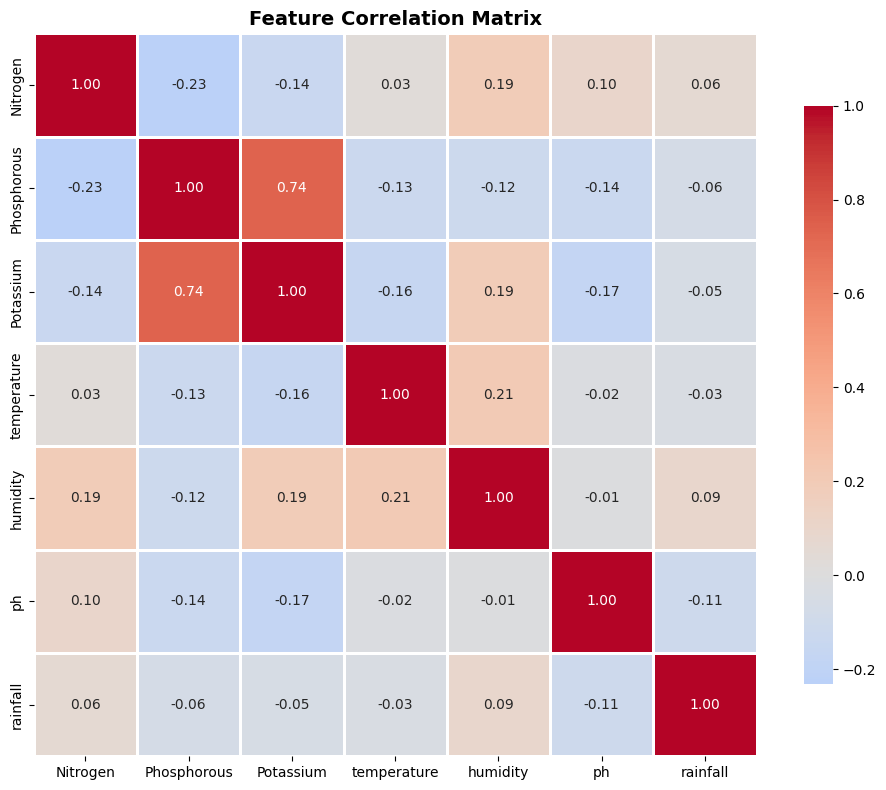

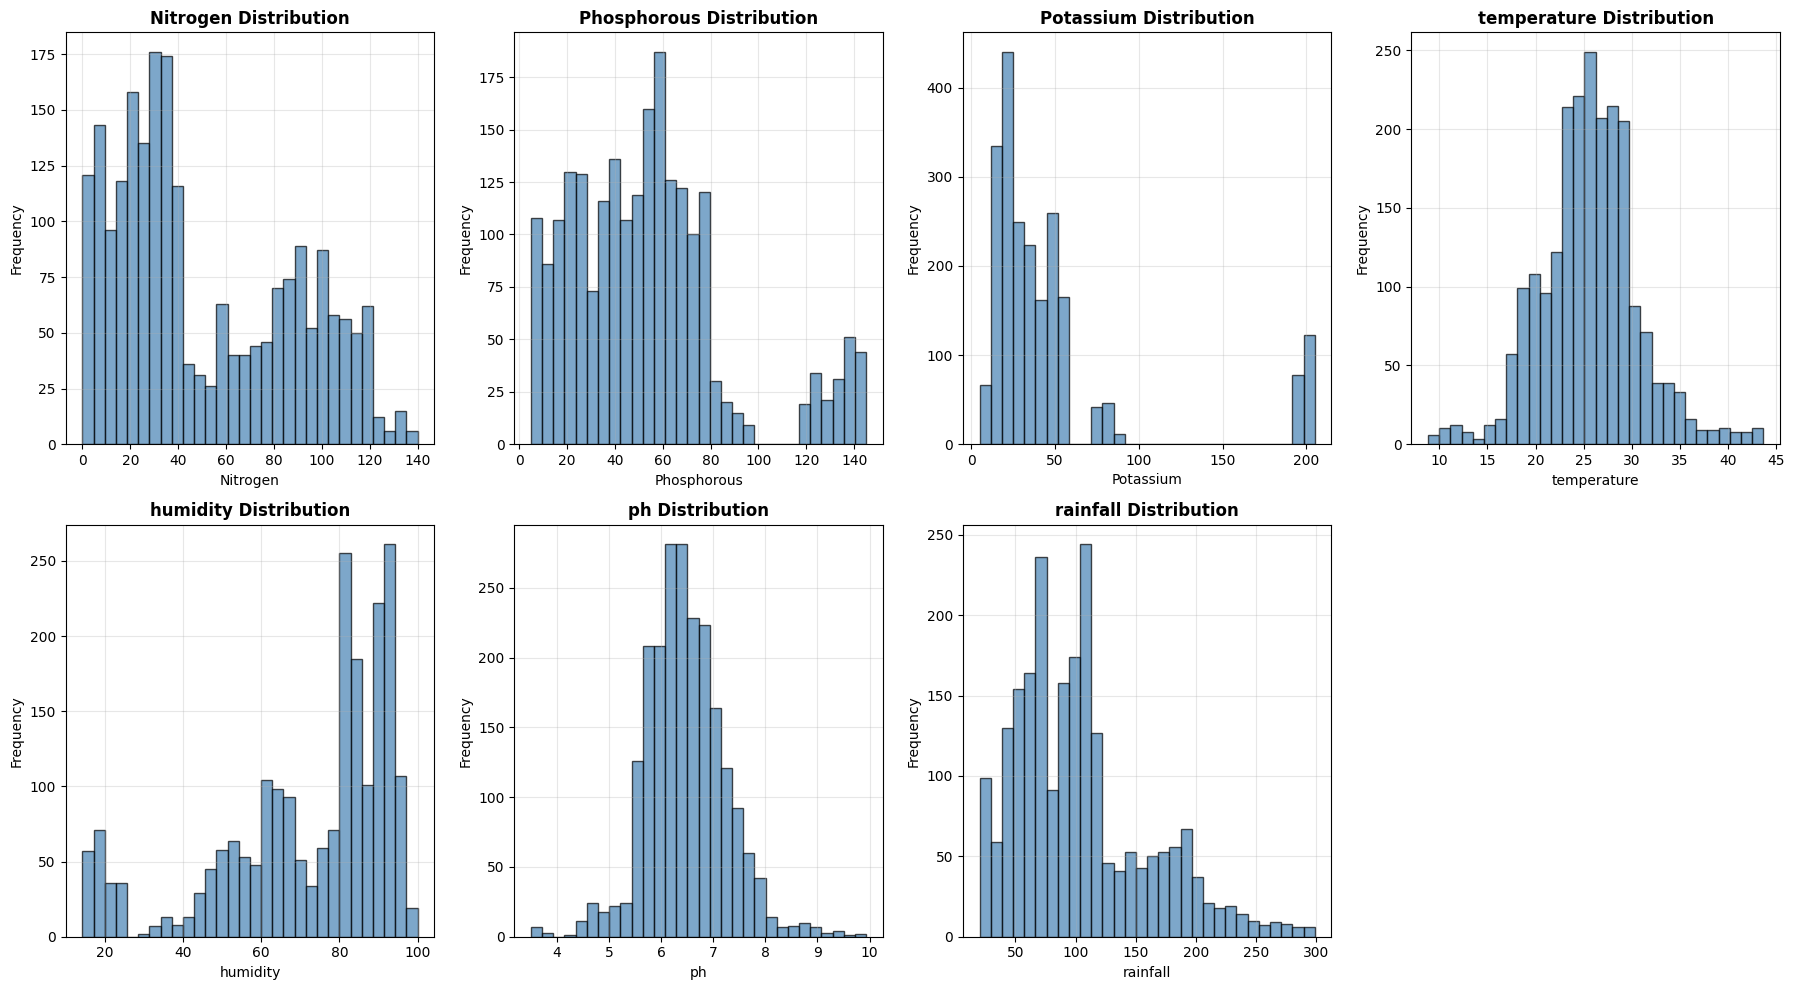

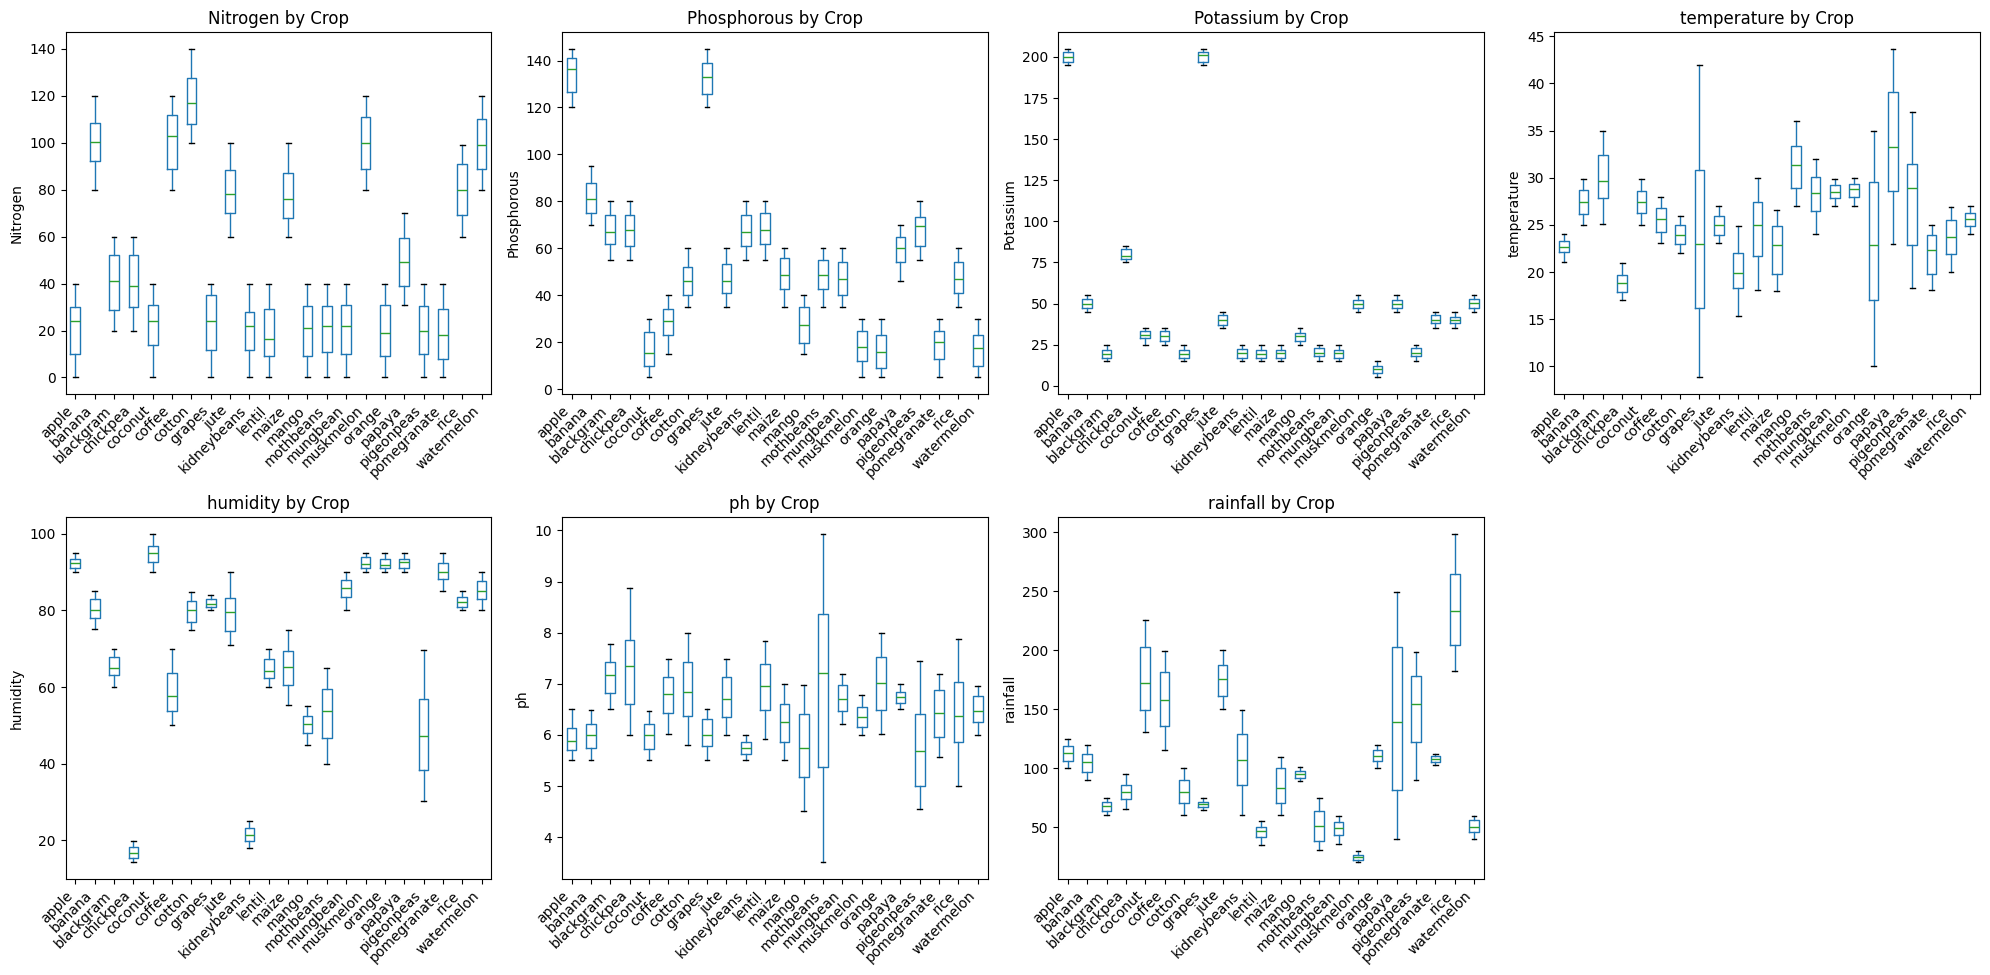


FEATURE ENGINEERING

✅ Original features: 7
✅ Total features after engineering: 18

New features created:
  - N_P_ratio
  - N_K_ratio
  - P_K_ratio
  - Total_NPK
  - N_dominance
  - temp_category
  - humidity_category
  - rainfall_category
  - ph_category
  - temp_humidity
  - temp_rainfall

DATA PREPARATION

Feature matrix shape: (2200, 18)
Target vector shape: (2200,)

Number of classes: 22
Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

✅ Training set: 1760 samples
✅ Test set: 440 samples

Training set class distribution:
  apple          :   80 (4.5%)
  banana         :   80 (4.5%)
  blackgram      :   80 (4.5%)
  chickpea       :   80 (4.5%)
  coconut        :   80 (4.5%)
  coffee         :   80 (4.5%)
  cotton         :   80 (4.5%)
  grapes         :   80 (4.5%)
  jute           :   80 (4.5%)

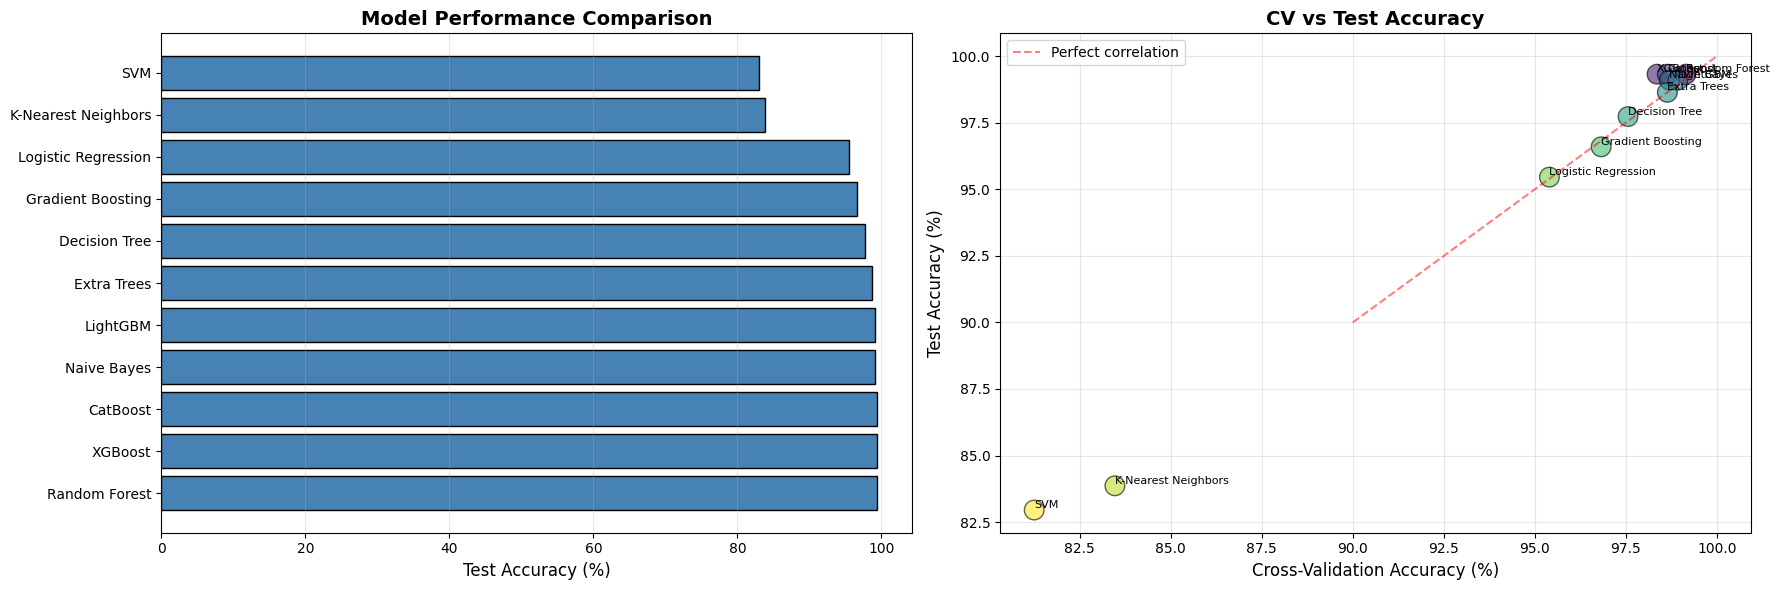


BEST MODEL EVALUATION

🏆 Best Model: Random Forest
   Test Accuracy: 99.32%

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
 

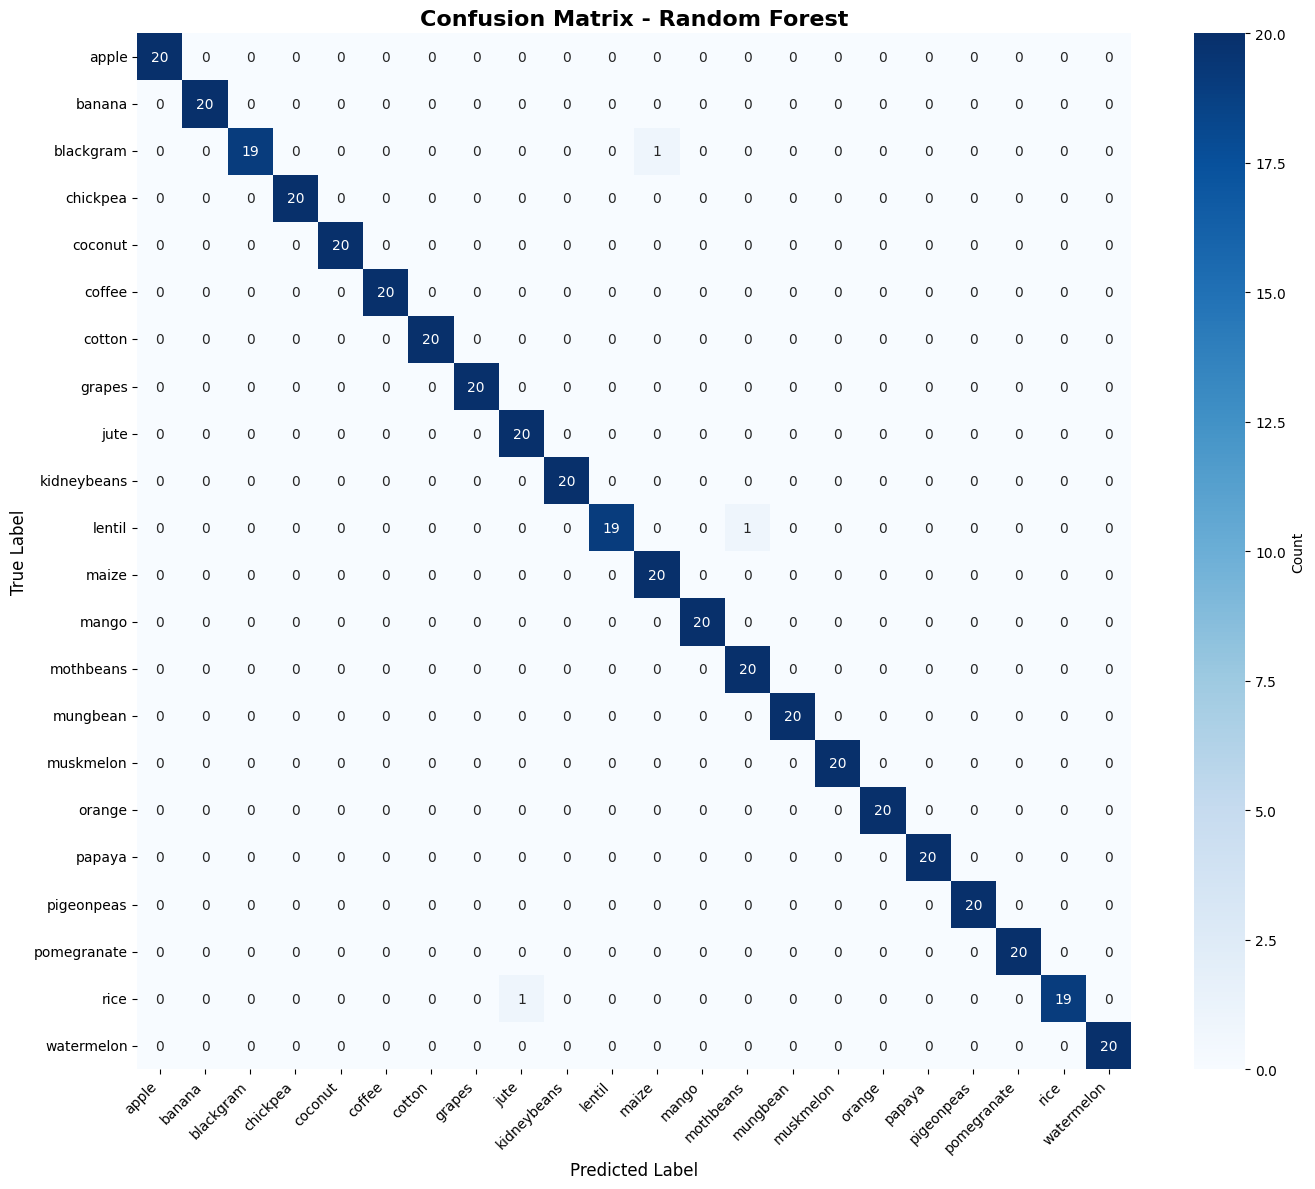


----------------------------------------------------------------------
PER-CLASS ACCURACY
----------------------------------------------------------------------
apple          : 100.00% ( 20 samples)
banana         : 100.00% ( 20 samples)
blackgram      :  95.00% ( 20 samples)
chickpea       : 100.00% ( 20 samples)
coconut        : 100.00% ( 20 samples)
coffee         : 100.00% ( 20 samples)
cotton         : 100.00% ( 20 samples)
grapes         : 100.00% ( 20 samples)
jute           : 100.00% ( 20 samples)
kidneybeans    : 100.00% ( 20 samples)
lentil         :  95.00% ( 20 samples)
maize          : 100.00% ( 20 samples)
mango          : 100.00% ( 20 samples)
mothbeans      : 100.00% ( 20 samples)
mungbean       : 100.00% ( 20 samples)
muskmelon      : 100.00% ( 20 samples)
orange         : 100.00% ( 20 samples)
papaya         : 100.00% ( 20 samples)
pigeonpeas     : 100.00% ( 20 samples)
pomegranate    : 100.00% ( 20 samples)
rice           :  95.00% ( 20 samples)
watermelon     : 10

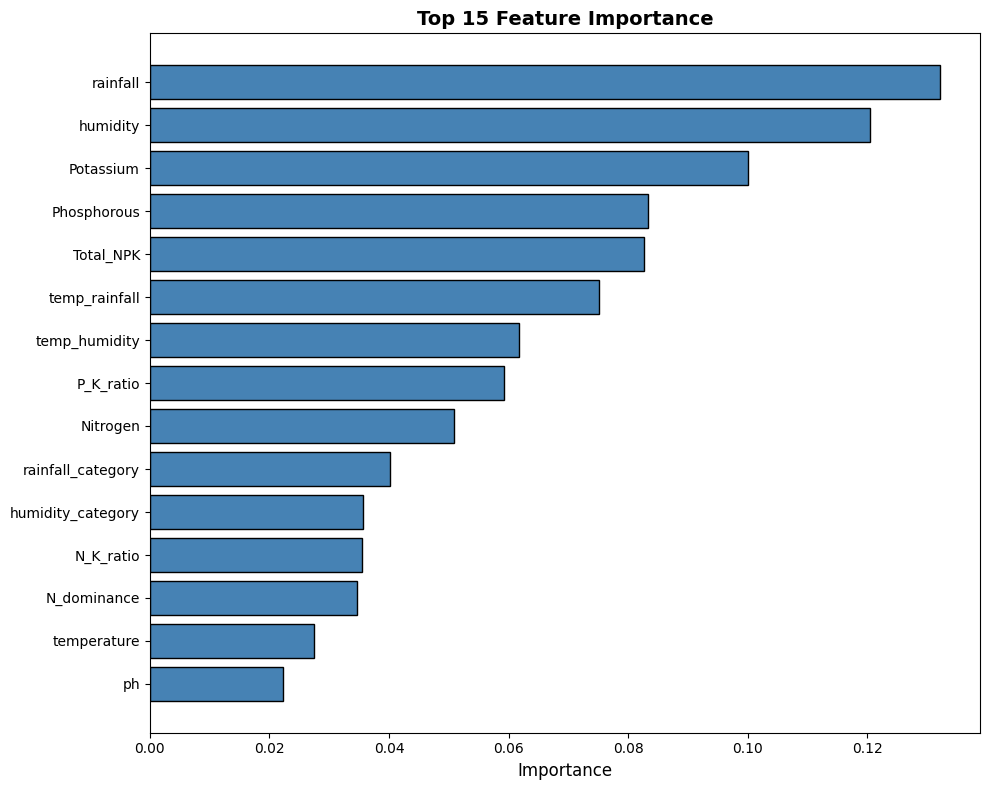


HYPERPARAMETER TUNING (Optional)

💡 To run hyperparameter tuning, uncomment the code block above.

ENSEMBLE MODEL

Creating ensemble from top 3 models:
  Random Forest       : 99.32%
  XGBoost             : 99.32%
  CatBoost            : 99.32%

🔄 Training ensemble model...
✅ Ensemble Test Accuracy: 99.55%
🎯 Ensemble is better! Improvement: +0.23%

SAVING MODELS
✅ Best model saved: best_crop_model.pkl (Ensemble (Top 3))
✅ Label encoder saved: crop_label_encoder.pkl
✅ Feature columns saved: feature_columns.pkl
✅ Complete package saved: crop_recommendation_complete.pkl

EXAMPLE PREDICTION

🌾 Recommended Crop: rice
   Confidence: 63.7%

   Top 3 Predictions:
   1. rice           : 63.7%
   2. coffee         : 14.2%
   3. jute           : 6.7%

✅ CROP RECOMMENDATION SYSTEM READY!

Best Model: Ensemble (Top 3)
Test Accuracy: 99.55%

Use predict_crop() function for new predictions!


In [1]:
"""
Crop Recommendation System - TABULAR DATA ONLY
High-accuracy crop prediction using soil nutrients and environmental factors

FEATURES:
1. Multiple ML algorithms comparison
2. Hyperparameter tuning
3. Feature engineering
4. Cross-validation
5. Comprehensive evaluation
"""

# ============================================================================
# CELL 1: INSTALL AND IMPORT DEPENDENCIES
# ============================================================================

!pip install -q xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings("ignore")

print("✅ All dependencies loaded successfully!")

# ============================================================================
# CELL 2: MOUNT GOOGLE DRIVE AND LOAD DATA
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/Crop_recommendation.csv')

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\n\nData Types:")
print(df.dtypes)

print(f"\n\nMissing Values:")
print(df.isnull().sum())

print(f"\n\nBasic Statistics:")
print(df.describe())

# Check crop distribution
print(f"\n\nCrop Distribution:")
print(df['label'].value_counts())

plt.figure(figsize=(14, 6))
df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Crop Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crop_distribution.png', dpi=300)
plt.show()

# ============================================================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Rename columns for clarity
df.rename(columns={"N": "Nitrogen", "P": "Phosphorous", "K": "Potassium"}, inplace=True)

# Correlation analysis
print("\n📊 Feature Correlations:")
numeric_cols = ['Nitrogen', 'Phosphorous', 'Potassium', 'temperature', 'humidity', 'ph', 'rainfall']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Distribution plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

axes[7].axis('off')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300)
plt.show()

# Boxplots by crop
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='label', ax=axes[i], grid=False)
    axes[i].set_title(f'{col} by Crop')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45, ha='right')

axes[7].axis('off')
plt.suptitle('')
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=300)
plt.show()

# ============================================================================
# CELL 4: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

# Create a copy for feature engineering
df_engineered = df.copy()

# 1. NPK Ratios (important for agriculture)
df_engineered['N_P_ratio'] = df_engineered['Nitrogen'] / (df_engineered['Phosphorous'] + 1)
df_engineered['N_K_ratio'] = df_engineered['Nitrogen'] / (df_engineered['Potassium'] + 1)
df_engineered['P_K_ratio'] = df_engineered['Phosphorous'] / (df_engineered['Potassium'] + 1)

# 2. Total NPK
df_engineered['Total_NPK'] = (df_engineered['Nitrogen'] +
                               df_engineered['Phosphorous'] +
                               df_engineered['Potassium'])

# 3. Nitrogen dominance
df_engineered['N_dominance'] = df_engineered['Nitrogen'] / (df_engineered['Total_NPK'] + 1)

# 4. Temperature categories
df_engineered['temp_category'] = pd.cut(df_engineered['temperature'],
                                         bins=[0, 15, 25, 50],
                                         labels=['cool', 'moderate', 'hot'])

# 5. Humidity categories
df_engineered['humidity_category'] = pd.cut(df_engineered['humidity'],
                                             bins=[0, 50, 70, 100],
                                             labels=['low', 'medium', 'high'])

# 6. Rainfall categories
df_engineered['rainfall_category'] = pd.cut(df_engineered['rainfall'],
                                             bins=[0, 100, 200, 300],
                                             labels=['low', 'medium', 'high'])

# 7. pH categories
df_engineered['ph_category'] = pd.cut(df_engineered['ph'],
                                       bins=[0, 5.5, 7.5, 14],
                                       labels=['acidic', 'neutral', 'alkaline'])

# 8. Interaction features
df_engineered['temp_humidity'] = df_engineered['temperature'] * df_engineered['humidity']
df_engineered['temp_rainfall'] = df_engineered['temperature'] * df_engineered['rainfall']

# Encode categorical features
label_encoders = {}
for col in ['temp_category', 'humidity_category', 'rainfall_category', 'ph_category']:
    le = LabelEncoder()
    df_engineered[col] = le.fit_transform(df_engineered[col])
    label_encoders[col] = le

print(f"\n✅ Original features: {len(numeric_cols)}")
print(f"✅ Total features after engineering: {len(df_engineered.columns) - 1}")  # -1 for label
print(f"\nNew features created:")
new_features = [col for col in df_engineered.columns if col not in df.columns]
for feat in new_features:
    print(f"  - {feat}")

# ============================================================================
# CELL 5: PREPARE DATA FOR MODELING
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Encode target variable
label_encoder = LabelEncoder()
df_engineered['label_encoded'] = label_encoder.fit_transform(df_engineered['label'])

# Select features (all except original label and encoded label)
feature_cols = [col for col in df_engineered.columns if col not in ['label', 'label_encoded']]

X = df_engineered[feature_cols]
y = df_engineered['label_encoded']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nNumber of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_}")

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")

# Check class distribution
print(f"\nTraining set class distribution:")
train_dist = Counter(y_train)
for class_idx in sorted(train_dist.keys()):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"  {class_name:15s}: {train_dist[class_idx]:4d} ({train_dist[class_idx]/len(y_train)*100:.1f}%)")

# ============================================================================
# CELL 6: TRAIN MULTIPLE MODELS AND COMPARE
# ============================================================================

print("\n" + "="*70)
print("MODEL TRAINING AND COMPARISON")
print("="*70)

# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=10,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.1,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        random_state=42
    )
}

results = []

print("\n🔄 Training models...\n")

for name, model in models.items():
    print(f"Training {name}...", end=' ')

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results.append({
        'Model': name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'F1 Score': f1,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    })

    print(f"✓ Test Acc: {test_accuracy*100:.2f}%")

# Results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
print(results_df.to_string(index=False))

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Test Accuracy comparison
ax1.barh(results_df['Model'], results_df['Test Accuracy']*100, color='steelblue', edgecolor='black')
ax1.set_xlabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# CV Mean vs Test Accuracy
ax2.scatter(results_df['CV Mean']*100, results_df['Test Accuracy']*100,
           s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis', edgecolors='black')
for idx, row in results_df.iterrows():
    ax2.annotate(row['Model'], (row['CV Mean']*100, row['Test Accuracy']*100),
                fontsize=8, ha='left', va='bottom')
ax2.plot([90, 100], [90, 100], 'r--', alpha=0.5, label='Perfect correlation')
ax2.set_xlabel('Cross-Validation Accuracy (%)', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('CV vs Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

# ============================================================================
# CELL 7: SELECT AND EVALUATE BEST MODEL
# ============================================================================

print("\n" + "="*70)
print("BEST MODEL EVALUATION")
print("="*70)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {results_df.iloc[0]['Test Accuracy']*100:.2f}%")

# Detailed evaluation
y_pred = best_model.predict(X_test)

print("\n" + "-"*70)
print("CLASSIFICATION REPORT")
print("-"*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_,
           cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\n" + "-"*70)
print("PER-CLASS ACCURACY")
print("-"*70)
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test == i
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_test[class_mask], y_pred[class_mask])
        print(f"{class_name:15s}: {class_acc*100:6.2f}% ({class_mask.sum():3d} samples)")

# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "-"*70)
    print("TOP 15 FEATURE IMPORTANCE")
    print("-"*70)

    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(feature_importance_df.head(15).to_string(index=False))

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300)
    plt.show()

# ============================================================================
# CELL 8: HYPERPARAMETER TUNING (OPTIONAL - SLOW)
# ============================================================================

print("\n" + "="*70)
print("HYPERPARAMETER TUNING (Optional)")
print("="*70)

# Uncomment to run hyperparameter tuning
"""
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [200, 300, 400],
        'max_depth': [15, 20, 25],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [200, 300, 400],
        'max_depth': [8, 10, 12],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')

else:
    print(f"Hyperparameter tuning not configured for {best_model_name}")
    param_grid = None
    base_model = None

if param_grid is not None:
    print(f"\n🔍 Tuning {best_model_name}...")
    print(f"   Parameter grid: {len(param_grid)} parameters")

    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"\n✅ Best parameters: {grid_search.best_params_}")
    print(f"✅ Best CV score: {grid_search.best_score_*100:.2f}%")

    tuned_model = grid_search.best_estimator_
    tuned_accuracy = tuned_model.score(X_test, y_test)
    print(f"✅ Tuned model test accuracy: {tuned_accuracy*100:.2f}%")

    # Update best model if tuned version is better
    if tuned_accuracy > results_df.iloc[0]['Test Accuracy']:
        best_model = tuned_model
        print(f"\n🎯 Tuned model is better! Improvement: +{(tuned_accuracy - results_df.iloc[0]['Test Accuracy'])*100:.2f}%")
"""

print("\n💡 To run hyperparameter tuning, uncomment the code block above.")

# ============================================================================
# CELL 9: CREATE ENSEMBLE MODEL
# ============================================================================

print("\n" + "="*70)
print("ENSEMBLE MODEL")
print("="*70)

# Create voting ensemble of top 3 models
top_3_models = results_df.head(3)
print(f"\nCreating ensemble from top 3 models:")
for idx, row in top_3_models.iterrows():
    print(f"  {row['Model']:20s}: {row['Test Accuracy']*100:.2f}%")

ensemble_models = []
for model_name in top_3_models['Model']:
    ensemble_models.append((model_name, models[model_name]))

voting_clf = VotingClassifier(
    estimators=ensemble_models,
    voting='soft',
    n_jobs=-1
)

print("\n🔄 Training ensemble model...")
voting_clf.fit(X_train, y_train)

ensemble_accuracy = voting_clf.score(X_test, y_test)
print(f"✅ Ensemble Test Accuracy: {ensemble_accuracy*100:.2f}%")

if ensemble_accuracy > results_df.iloc[0]['Test Accuracy']:
    print(f"🎯 Ensemble is better! Improvement: +{(ensemble_accuracy - results_df.iloc[0]['Test Accuracy'])*100:.2f}%")
    best_model = voting_clf
    best_model_name = 'Ensemble (Top 3)'
else:
    print(f"Single model ({best_model_name}) is still better.")

# ============================================================================
# CELL 10: SAVE MODELS AND ARTIFACTS
# ============================================================================

print("\n" + "="*70)
print("SAVING MODELS")
print("="*70)

# Save best model
joblib.dump(best_model, 'best_crop_model.pkl')
print(f"✅ Best model saved: best_crop_model.pkl ({best_model_name})")

# Save label encoder
joblib.dump(label_encoder, 'crop_label_encoder.pkl')
print(f"✅ Label encoder saved: crop_label_encoder.pkl")

# Save feature names
joblib.dump(feature_cols, 'feature_columns.pkl')
print(f"✅ Feature columns saved: feature_columns.pkl")

# Save all models for later use
all_models = {
    'best_model': best_model,
    'label_encoder': label_encoder,
    'feature_cols': feature_cols,
    'all_models': models,
    'results': results_df
}
joblib.dump(all_models, 'crop_recommendation_complete.pkl')
print(f"✅ Complete package saved: crop_recommendation_complete.pkl")

# ============================================================================
# CELL 11: PREDICTION FUNCTION
# ============================================================================

def predict_crop(nitrogen, phosphorous, potassium, temperature,
                humidity, ph, rainfall, model=best_model, return_proba=True):
    """
    Predict crop recommendation

    Parameters:
    -----------
    nitrogen : float - Nitrogen content (0-140)
    phosphorous : float - Phosphorous content (5-145)
    potassium : float - Potassium content (5-205)
    temperature : float - Temperature in Celsius (8-43)
    humidity : float - Relative humidity (14-100)
    ph : float - Soil pH (3.5-10)
    rainfall : float - Rainfall in mm (20-300)

    Returns:
    --------
    dict with crop recommendation and confidence
    """

    # Create input dataframe with original features
    input_data = pd.DataFrame([{
        'Nitrogen': nitrogen,
        'Phosphorous': phosphorous,
        'Potassium': potassium,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])

    # Feature engineering (same as training)
    input_data['N_P_ratio'] = input_data['Nitrogen'] / (input_data['Phosphorous'] + 1)
    input_data['N_K_ratio'] = input_data['Nitrogen'] / (input_data['Potassium'] + 1)
    input_data['P_K_ratio'] = input_data['Phosphorous'] / (input_data['Potassium'] + 1)
    input_data['Total_NPK'] = (input_data['Nitrogen'] + input_data['Phosphorous'] + input_data['Potassium'])
    input_data['N_dominance'] = input_data['Nitrogen'] / (input_data['Total_NPK'] + 1)

    # Temperature category
    if temperature <= 15:
        input_data['temp_category'] = 0  # cool
    elif temperature <= 25:
        input_data['temp_category'] = 1  # moderate
    else:
        input_data['temp_category'] = 2  # hot

    # Humidity category
    if humidity <= 50:
        input_data['humidity_category'] = 0  # low
    elif humidity <= 70:
        input_data['humidity_category'] = 1  # medium
    else:
        input_data['humidity_category'] = 2  # high

    # Rainfall category
    if rainfall <= 100:
        input_data['rainfall_category'] = 0  # low
    elif rainfall <= 200:
        input_data['rainfall_category'] = 1  # medium
    else:
        input_data['rainfall_category'] = 2  # high

    # pH category
    if ph <= 5.5:
        input_data['ph_category'] = 0  # acidic
    elif ph <= 7.5:
        input_data['ph_category'] = 1  # neutral
    else:
        input_data['ph_category'] = 2  # alkaline

    # Interaction features
    input_data['temp_humidity'] = input_data['temperature'] * input_data['humidity']
    input_data['temp_rainfall'] = input_data['temperature'] * input_data['rainfall']

    # Ensure correct order
    input_data = input_data[feature_cols]

    # Predict
    prediction = model.predict(input_data)[0]
    crop_name = label_encoder.inverse_transform([prediction])[0]

    result = {
        'recommended_crop': crop_name,
        'crop_code': int(prediction)
    }

    # Get probabilities if available
    if return_proba and hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(input_data)[0]
        confidence = probabilities[prediction] * 100

        # Get top 3 predictions
        top_3_idx = np.argsort(probabilities)[-3:][::-1]
        top_3_crops = label_encoder.inverse_transform(top_3_idx)
        top_3_probs = probabilities[top_3_idx] * 100

        result['confidence'] = confidence
        result['top_3_predictions'] = list(zip(top_3_crops, top_3_probs))

    return result

# Example usage
print("\n" + "="*70)
print("EXAMPLE PREDICTION")
print("="*70)

example_result = predict_crop(
    nitrogen=90,
    phosphorous=42,
    potassium=43,
    temperature=20.8,
    humidity=82.0,
    ph=6.5,
    rainfall=202.9
)

print(f"\n🌾 Recommended Crop: {example_result['recommended_crop']}")
if 'confidence' in example_result:
    print(f"   Confidence: {example_result['confidence']:.1f}%")
    print(f"\n   Top 3 Predictions:")
    for i, (crop, prob) in enumerate(example_result['top_3_predictions'], 1):
        print(f"   {i}. {crop:15s}: {prob:.1f}%")

print("\n" + "="*70)
print("✅ CROP RECOMMENDATION SYSTEM READY!")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']*100:.2f}%" if best_model_name != 'Ensemble (Top 3)' else f"Test Accuracy: {ensemble_accuracy*100:.2f}%")
print(f"\nUse predict_crop() function for new predictions!")
print("="*70)

In [2]:
import joblib

# Suppose 'trained_model' is your trained model instance (e.g., model.fit(X_train, y_train) done)
# For example, if you select Random Forest: trained_model = models['Random Forest']

joblib.dump(model, 'my_crop_model.pkl')
print("✅ Model saved as 'my_crop_model.pkl'")


✅ Model saved as 'my_crop_model.pkl'
